# Notebook n°1: Milestone 1 (M1) Paired Feature Extraction (Audio ⊕ OEP)

**Pipeline stage:** Milestone 1 (M1) turns a raw recording (audio `.wav` + OEP `.csv` + sync pulse + Excel timing) into a single **time-aligned `[audio | OEP]` feature matrix**, saved as HDF5. Every later notebook consumes those HDF5 files.

**Scripts / module reproduced**
| Script / module | Role |
|-----------------|------|
| `pneumophonic_analysis/paired_features.py` | `PairedFeatureExtractor`, OEP feature computation, interpolation, HDF5 I/O |
| `scripts/test_paired.py` | interactive single-recording extraction |
| `scripts/batch_extract.py` | batch extraction across all subjects (the `TASK_MAP`) |

**The extraction pipeline** (`PairedFeatureExtractor.extract`):
1. load audio, sync pulse, and OEP CSV (`io_utils.DataLoader`)
2. synchronize via the Excel **falling-edge** time (`sync.py`)
3. auto-trim to the actual phonation window
4. extract frame-level audio features (pYIN F0, energy, spectral centroid, MFCCs) at ~66.7 fps
5. compute OEP volumes and flows at 50 Hz, then **interpolate onto the audio frame grid**
6. merge into one DataFrame and write HDF5 (plus STFT/mel/MFCC matrices)

> The raw `.wav`/`.csv` are not committed, so steps 4 to 6 are shown on **synthetic OEP** plus a **real extracted HDF5** output. Plot types: OEP volumes, OEP flows, native-vs-interpolated resampling overlay, and the final aligned audio ⊕ OEP matrix.

## 0. Setup

In [1]:

import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / "pneumophonic_analysis").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from pneumophonic_analysis import create_config
from pneumophonic_analysis.paired_features import (
    PairedFeatureExtractor, compute_oep_features_native, interpolate_oep_to_audio_frames)
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
CFG = create_config()


# --- Presentation-safe subject aliases (figures may be reused in talks) -----
# Real IDs stay in code; titles show a stable generic alias ("S01".."S39"),
# assigned by alphabetical order of the corpus and identical across notebooks.
def _build_alias():
    _pdir = REPO / "data_target" / "healthy_subjects" / "paired"
    _sids = sorted({f.stem.split('_', 1)[0] for f in _pdir.glob('*.h5')})
    return {s: f"S{i+1:02d}" for i, s in enumerate(_sids)}
ALIAS = _build_alias()
def anon(sid): return ALIAS.get(sid, sid)

## 1. The OEP column model
The OEP `.csv` is space-separated with these columns. The two-compartment model splits the chest wall into rib cage (`Vrc = A + B`) and abdomen (`Vab = C`), and `A + B + C = tot_vol` (Vcw).

| Column | Label | Quantity |
|--------|-------|----------|
| 1 | `time` | time (s) |
| 2 | `A` | Vrcp: pulmonary rib-cage volume (L) |
| 3 | `B` | Vrca: abdominal rib-cage volume (L) |
| 4 | `C` | Vab: abdominal volume (L) |
| 5 | `tot_vol` | Vcw: total chest-wall volume (L) |
| 6 | `sync` | synchronization signal |

In [2]:

# Synthetic OEP recording at 50 Hz: breathing oscillation + an expiratory deflation during phonation
fs_oep = CFG.oep.fs_kinematic     # 50 Hz
dur = 12.0
t = np.arange(int(fs_oep*dur)) / fs_oep
osc  = 0.08*np.sin(2*np.pi*0.30*t)            # quiet-breathing oscillation
ramp = np.clip((t-2.0)/8.0, 0, 1)            # phonation expiration 2 s -> 10 s
A = 1.10 + 0.5*osc - 0.35*ramp                # Vrcp
B = 0.60 + 0.3*osc - 0.15*ramp                # Vrca
C = 1.30 + 1.0*osc - 0.50*ramp                # Vab
tot = A + B + C                               # Vcw
sync = np.zeros_like(t); sync[50:60] = 1.0    # 1-s sync pulse
oep_df = pd.DataFrame({'time': t, 'A': A, 'B': B, 'C': C, 'tot_vol': tot, 'sync': sync})
print(f"Synthetic OEP: {len(oep_df)} samples @ {fs_oep} Hz ({dur:.0f}s)")
print(f"A+B+C == tot_vol ? max abs error = {(oep_df.A+oep_df.B+oep_df.C-oep_df.tot_vol).abs().max():.2e}")
oep_df.head()

Synthetic OEP: 600 samples @ 50 Hz (12s)
A+B+C == tot_vol ? max abs error = 0.00e+00


,time,A,B,C,tot_vol,sync
0,0.00,1.100000,0.600000,1.300000,3.000000,0.0
1,0.02,1.101508,0.600905,1.303015,3.005427,0.0
2,0.04,1.103013,0.601808,1.306026,3.010847,0.0
3,0.06,1.104514,0.602709,1.309029,3.016251,0.0
4,0.08,1.106009,0.603605,1.312018,3.021632,0.0


## 2. OEP feature computation (native rate, auto-detected)
`compute_oep_features_native` derives the compartmental volumes, then the **flows** (numerical derivative of a 10 Hz Butterworth-filtered volume × the k=0.916 calibration factor), and the instantaneous compartmental ratios.

> **OEP sample rate.** Acquisitions are not uniform: some OEP CSVs are 50 Hz, others 100 Hz. `extract()` now reads the true rate from each CSV's `time` column. Using the wrong rate would time-stretch the OEP and desync it from the audio.

derived columns: ['time_oep', 'vcw', 'vrc', 'vab', 'vrcp', 'vrca', 'flow_cw', 'flow_rc', 'flow_ab', 'pct_rc', 'pct_ab', 'delta_vcw', 'delta_vrc', 'delta_vab']


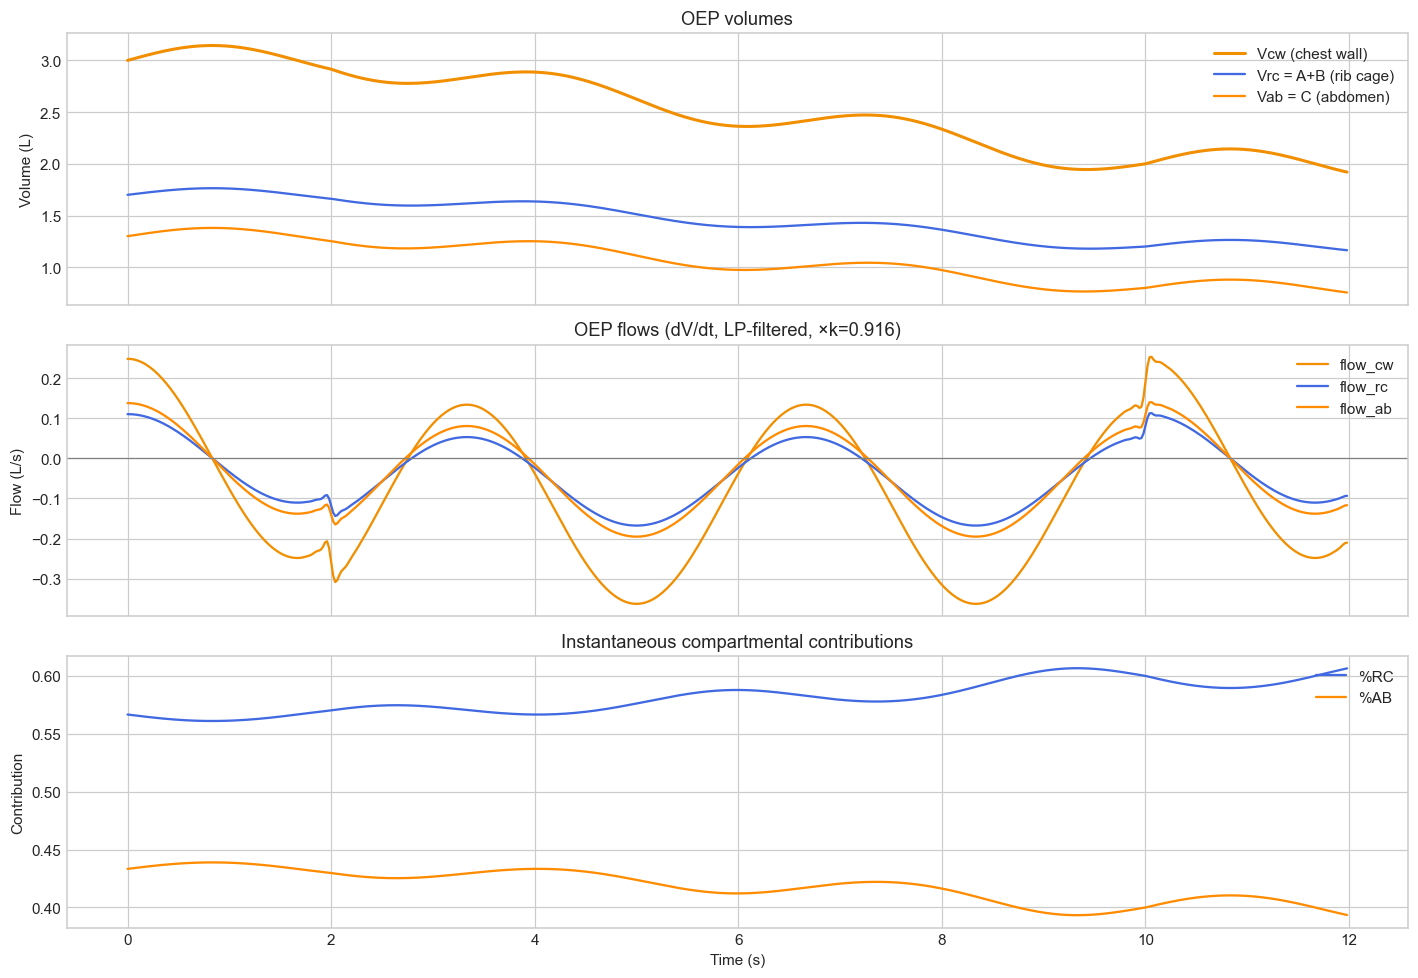

In [3]:

native = compute_oep_features_native(oep_df, fs_oep=fs_oep)
print("derived columns:", list(native.columns))

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
axes[0].plot(t, native['vcw'], label='Vcw (chest wall)', color='#F18F01', lw=2)
axes[0].plot(t, native['vrc'], label='Vrc = A+B (rib cage)', color='royalblue')
axes[0].plot(t, native['vab'], label='Vab = C (abdomen)', color='darkorange')
axes[0].set_ylabel('Volume (L)'); axes[0].legend(loc='upper right'); axes[0].set_title('OEP volumes')
axes[1].plot(t, native['flow_cw'], label='flow_cw', color='#F18F01')
axes[1].plot(t, native['flow_rc'], label='flow_rc', color='royalblue')
axes[1].plot(t, native['flow_ab'], label='flow_ab', color='darkorange')
axes[1].axhline(0, color='gray', lw=0.8); axes[1].set_ylabel('Flow (L/s)')
axes[1].legend(loc='upper right'); axes[1].set_title('OEP flows (dV/dt, LP-filtered, ×k=0.916)')
axes[2].plot(t, native['pct_rc'], label='%RC', color='royalblue')
axes[2].plot(t, native['pct_ab'], label='%AB', color='darkorange')
axes[2].set_ylabel('Contribution'); axes[2].set_xlabel('Time (s)')
axes[2].legend(loc='upper right'); axes[2].set_title('Instantaneous compartmental contributions')
plt.tight_layout(); plt.show()

**Observations:**\
Synthetic OEP recording (notebook n°1 demo), not a real subject.\
`Vrc + Vab = Vcw`, and `%RC + %AB = 1`, by construction.\
Flows are the time-derivatives of the measured volumes, crossing zero at the volume turning points (middle panel).\
Breathing strategy varies between subjects: the same task can lean more on the abdomen or the rib cage.\
This figure shows one example strategy only.

## 3. Resampling OEP onto the audio frame grid
Audio features land on a ~66.7 fps grid (hop 720 @ 48 kHz); **OEP is at 50 Hz**. `interpolate_oep_to_audio_frames`
linearly resamples the (band-limited) OEP signals onto the audio grid so the two streams share one
time axis.

native: 600 samples @ 50 Hz  ->  interpolated: 800 frames @ 66.7 fps


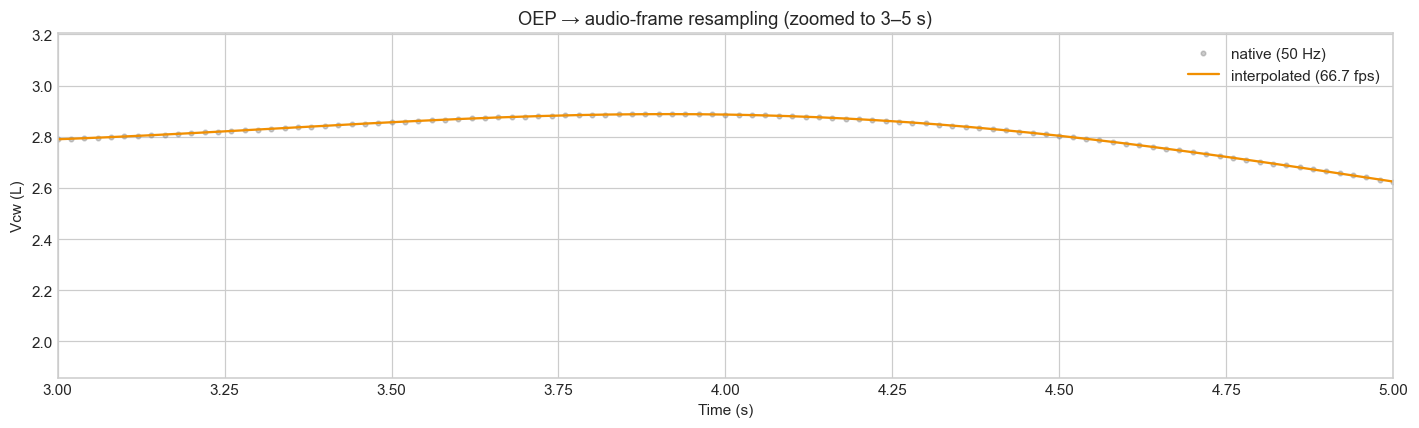

In [4]:

SR = CFG.audio.sample_rate; HOP = CFG.audio.hop_length_samples
audio_frame_times = np.arange(0, dur, HOP/SR)
oep_interp = interpolate_oep_to_audio_frames(native, audio_frame_times)
print(f"native: {len(t)} samples @ {fs_oep} Hz  ->  interpolated: {len(audio_frame_times)} frames @ {SR/HOP:.1f} fps")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t, native['vcw'], 'o', ms=3, alpha=0.4, color='gray', label=f'native ({fs_oep} Hz)')
ax.plot(oep_interp.time, oep_interp.vcw, '-', color='#F18F01', lw=1.5, label=f'interpolated ({SR/HOP:.1f} fps)')
ax.set_xlim(3, 5); ax.set_xlabel('Time (s)'); ax.set_ylabel('Vcw (L)')
ax.set_title('OEP → audio-frame resampling (zoomed to 3–5 s)'); ax.legend(); plt.tight_layout(); plt.show()

**Observations:**\
Synthetic OEP recording (notebook n°1 demo), zoomed to 3 to 5 s.\
The linear interpolation rides exactly through the native 50/100 Hz samples (gray dots) and fills the ~66 fps audio grid, with no smoothing or phase shift.\
The OEP is the limiting resolution: breathing kinematics stay below ~10 Hz.\
Upsampling only aligns it to the audio frames; it adds no information.

## 4. The batch task map
`batch_extract.py` resolves each task label to its audio file and OEP CSV; the Excel falling-edge
column drives the sync. Running it over a cohort produces one HDF5 per subject × task plus an
`extraction_summary.csv`.

In [5]:

TASK_MAP = {
    'a': ('a.wav','Vocali'), 'e': ('e.wav','Vocali'), 'i': ('i.wav','Vocali'),
    'o': ('o.wav','Vocali'), 'u': ('u.wav','Vocali'),
    'a_2': ('phonema_a_2.wav','phonema_a_2'), 'a_3': ('phonema_a_3.wav','phonema_a_3'),
    'a_7': ('phonema_a_7_2.wav','phonema_a_7'), 'r': ('r.wav','r'),
    'f_1': ('phrase_1.wav','frasi'), 'f_2': ('phrase_2.wav','frasi'), 'f_3': ('phrase_3.wav','frasi'),
    'f_4': ('phrase_4.wav','frasi'), 'f_5': ('phrase_5.wav','frasi'), 'testo': ('testo.wav','testo'),
}
display(pd.DataFrame([(k, v[0], f"csv/<ID>_{v[1]}.csv") for k, v in TASK_MAP.items()],
                     columns=['task', 'audio file', 'OEP CSV']))

,task,audio file,OEP CSV
0,a,a.wav,csv/<ID>_Vocali.csv
1,e,e.wav,csv/<ID>_Vocali.csv
2,i,i.wav,csv/<ID>_Vocali.csv
3,o,o.wav,csv/<ID>_Vocali.csv
4,u,u.wav,csv/<ID>_Vocali.csv
5,a_2,phonema_a_2.wav,csv/<ID>_phonema_a_2.csv
6,a_3,phonema_a_3.wav,csv/<ID>_phonema_a_3.csv
7,a_7,phonema_a_7_2.wav,csv/<ID>_phonema_a_7.csv
8,r,r.wav,csv/<ID>_r.csv
9,f_1,phrase_1.wav,csv/<ID>_frasi.csv


## 5. A real extracted HDF5: the Milestone 1 (M1) output
Task `a_2` (maximum phonation time on /a/), one example subject.\
Loading a real extracted recording shows exactly what `extract()` + `save_hdf5` produce: the aligned matrix, the metadata (including the sync `sync_time_offset_sec`), and the compartmental sanity check `Vrc + Vab = Vcw`.

In [6]:

PAIRED_DIR = REPO / "data_target" / "healthy_subjects" / "paired"
h5_files = sorted(PAIRED_DIR.glob("*.h5"))
if not h5_files:
    print("No extracted HDF5 found — run scripts/batch_extract.py first.")
else:
    H5 = next((f for f in h5_files if f.stem.endswith('_a_2')), h5_files[0])
    df, meta = PairedFeatureExtractor.load_hdf5(H5)
    print(f"{H5.name}: {df.shape[0]} frames x {df.shape[1]} features")
    print("metadata:", {k: meta[k] for k in ['subject_id','task_name','sr_audio','fs_oep','hop_length',
          'n_frames','audio_duration_sec','sync_time_offset_sec','calibration_k']})
    err = (df['vrc'] + df['vab'] - df['vcw']).abs().mean()
    print(f"compartmental check |Vrc+Vab-Vcw| = {err:.2e} L")
    display(df[['time','f0','energy','spectral_centroid','vcw','vrc','vab','flow_cw','pct_rc']].head())

AlMo_a_2.h5: 1086 frames x 35 features
metadata: {'subject_id': 'AlMo', 'task_name': 'a_2', 'sr_audio': 48000, 'fs_oep': 50, 'hop_length': 720, 'n_frames': 1086, 'audio_duration_sec': 16.278645833333336, 'sync_time_offset_sec': -56.696000000000005, 'calibration_k': 0.916}
compartmental check |Vrc+Vab-Vcw| = 3.25e-07 L


,time,f0,energy,spectral_centroid,vcw,vrc,vab,flow_cw,pct_rc
0,0.000,NaN,0.000019,220.002859,23.090599,16.311310,6.779289,-1.011829,0.706405
1,0.015,NaN,0.000140,167.977297,23.076970,16.306515,6.770455,-0.975035,0.706614
2,0.030,120.999409,0.017480,39.827573,23.059429,16.301138,6.758291,-0.870549,0.706919
3,0.045,125.266444,0.076630,34.379918,23.043624,16.295879,6.747745,-0.691615,0.707175
4,0.060,125.266444,0.204301,33.057747,23.035207,16.291439,6.743768,-0.431477,0.707241


### 5b. The aligned result
Task `a_2` (maximum phonation time on /a/), one example subject.\
**Audio energy and chest-wall volume now share one time axis.** This coupling is studied deeper in Milestone 2 (M2), notebook n°3.

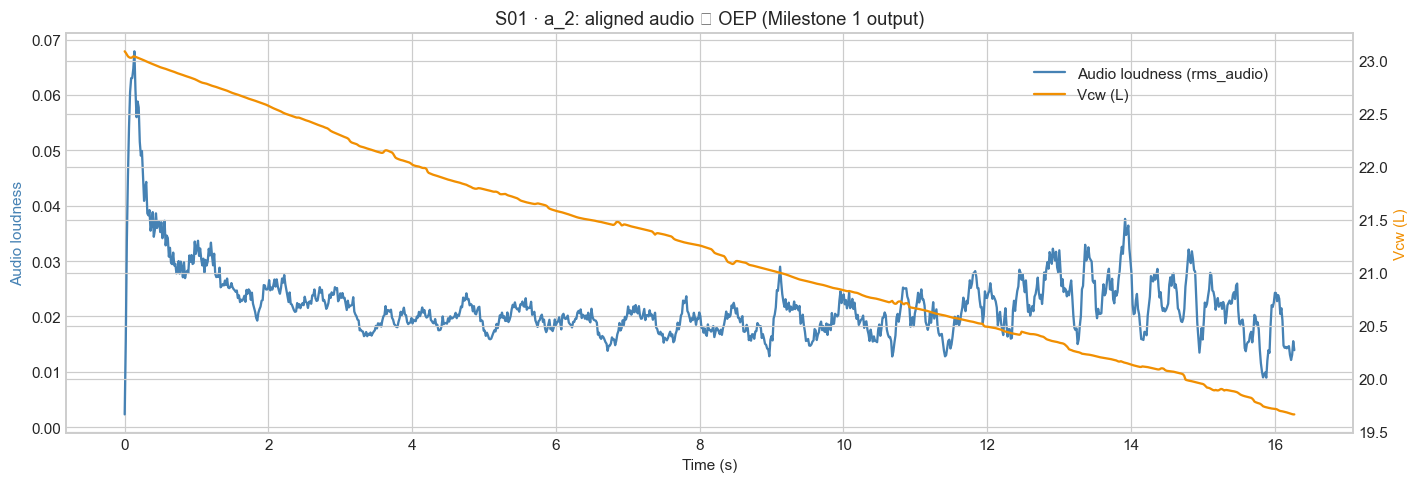

In [7]:

if h5_files:
    fig, ax1 = plt.subplots(figsize=(13, 4.5))
    amp = df['rms_audio'] if 'rms_audio' in df.columns else df['energy']
    ax1.plot(df['time'], amp, color='steelblue', label='Audio loudness (rms_audio)')
    ax1.set_ylabel('Audio loudness', color='steelblue'); ax1.set_xlabel('Time (s)')
    ax2 = ax1.twinx(); ax2.plot(df['time'], df['vcw'], color='#F18F01', label='Vcw (L)')
    ax2.set_ylabel('Vcw (L)', color='#F18F01')
    ax1.set_title(f"{anon(meta['subject_id'])} · {meta['task_name']}: aligned audio ⊕ OEP (Milestone 1 output)")
    fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88)); plt.tight_layout(); plt.show()

**Observations:**\
Task `a_2` (maximum phonation time on /a/), one example subject.\
Loudness (`rms_audio`) stays roughly sustained while `Vcw` falls steadily: a held vowel driven by controlled expiration.\
This shared time axis (audio ⊕ OEP) is the Milestone 1 (M1) output that everything downstream sits on.\
We plot `rms_audio`, the raw-audio loudness, rather than the onset-spiking `energy` feature.

## 6. Run Milestone 1 (M1) on *new* data: file browser

The raw `.wav`/`.csv` recordings are not committed to this repo (they were removed because the folders were too large).

To extract new datasets wherever they live on disk, this cell opens a native **folder browser**: pick each subject folder (one containing `renders/`, `csv/`, `sync_signal.wav`, `<ID>_audio.xlsx`), press **Cancel** when done, then enter a batch label. It reuses `scripts/batch_extract.py` so the task map, Excel-timing sync, and HDF5 writing are identical.

> The cell is **guarded** by `RUN_EXTRACTION = False` so *Run All* and headless execution never block on a dialog. Flip it to `True` and run just this cell to extract. Equivalent terminal command: `python scripts/batch_extract.py`.

In [8]:
RUN_EXTRACTION = False   # set True and run the cell to choose the folder(s) to ectract

if RUN_EXTRACTION:
    sys.path.insert(0, str(REPO / "scripts"))
    import batch_extract as be          # safe to import (its run-flow is __main__-guarded)
    picked = be.expand_selection(be.select_subject_folders_gui(
        title="Select subject folder(s) to extract", initialdir=str(REPO)))
    if picked:
        print("Selected:", *[f"\n  - {p}" for p in picked])
        batch = input("Batch label [healthy_subjects]: ").strip() or "healthy_subjects"
        summary = be.run_batch(picked, batch)
        display(summary)
    else:
        print("No folders selected.")
else:
    print("RUN_EXTRACTION is False — flip it to True to open a file browser and extract your data.")
    print("Terminal equivalent:  python scripts/batch_extract.py")

RUN_EXTRACTION is False — flip it to True to open a file browser and extract your data.
Terminal equivalent:  python scripts/batch_extract.py


## Recap
Milestone 1 (M1) merges two acquisition systems running at different rates (OEP and audio) into one analysis-ready matrix. To run it for real:

```bash
python scripts/test_paired.py      # one recording, interactive
python scripts/batch_extract.py    # whole cohort -> data_target/<batch>/paired/*.h5
```

Then continue with notebook n°2 (visualization) and notebook n°3 (Milestone 2 (M2) correlation).